# EDA - Análisis Exploratorio de Datos

## Importación de librerías

In [1]:
## Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de rutas
from pathlib import Path

# Configuración de librerías y estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
import warnings
warnings.filterwarnings('ignore')




## Estructura del dataset

In [2]:
# Ruta de los datasets.
DATA_RAW = Path("../data/raw") 

# Carga del dataset.
df_master = pd.read_csv(DATA_RAW / "marvel_master.csv")
df_rag = pd.read_csv(DATA_RAW / "marvel_rag.csv")
df_ratings = pd.read_csv(DATA_RAW / "marvel_ratings.csv")
df_cast = pd.read_csv(DATA_RAW / "marvel_cast.csv")

# Dimensiones de cada dataset.
print(f'El dataset master tiene {df_master.shape[0]} filas y {df_master.shape[1]} columnas.')
print(f'El dataset RAG tiene {df_rag.shape[0]} filas y {df_rag.shape[1]} columnas.')
print(f'El dataset ratings tiene {df_ratings.shape[0]} filas y {df_ratings.shape[1]} columnas.')
print(f'El dataset cast tiene {df_cast.shape[0]} filas y {df_cast.shape[1]} columnas.')


El dataset master tiene 161 filas y 50 columnas.
El dataset RAG tiene 161 filas y 6 columnas.
El dataset ratings tiene 554 filas y 4 columnas.
El dataset cast tiene 1628 filas y 9 columnas.


## Vista general de `marvel_master.csv` (Tabla de hechos)

In [3]:
df_master.head(3)

,id,title,year,imdb_id,type,rated,runtime_min,genre,director,writer,actors,plot,language,country,awards,imdb_rating,imdb_votes,rt_score,metacritic_score,box_office_usd,production,website,mcu_phase,universe,decade,age_years,is_animated,is_tv_series,is_mcu_canon,tmdb_id,tmdb_genres,budget_usd,revenue_usd,tmdb_rating,tmdb_votes,popularity,top5_cast,directors,producers,composer,tmdb_keywords,collection_name,poster_url,production_countries,spoken_languages,episode_count,season_count,network,status,tagline
0,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Elmer Clifton, John English","Royal K. Cole, Ronald Davidson, Basil Dickey","Dick Purcell, Lorna Gray, Lionel Atwill",Superhero Captain America battles the evil for...,English,United States,NaN,5.3,"1,144",NaN,NaN,NaN,NaN,NaN,Pre-MCU,Pre-MCU,1940s,81,0,0,0,106355.0,"Action, Adventure, Science Fiction",0.0,0.0,5.4,34.0,0.8143,"Dick Purcell, Lorna Gray, Lionel Atwill, Charl...","John English, Elmer Clifton",NaN,NaN,"superhero, based on comic, masked vigilante, m...",NaN,https://image.tmdb.org/t/p/w500/nBRcChS66NohR3...,United States of America,English,NaN,NaN,NaN,Released,NaN
1,2,The Amazing Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",NaN,NaN,"Nicholas Hammond, Robert F. Simon, Chip Fields",With the powers given by the bite of a radioac...,English,United States,NaN,6.2,"2,778",NaN,NaN,NaN,NaN,NaN,Pre-MCU,Sony / Spider-Man,1970s,48,0,1,0,225914.0,"Science Fiction, Action, Crime",0.0,0.0,6.3,212.0,1.7517,"Nicholas Hammond, David White, Michael Pataki,...",E.W. Swackhamer,Edward Montagne,Craig Huxley,"mind control, new york city, photographer, sec...",Spider-Man (TV) Collection,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,NaN,NaN,NaN,Released,The world's favorite adventure super hero in l...
2,3,Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",NaN,NaN,"Nicholas Hammond, Robert F. Simon, Chip Fields",With the powers given by the bite of a radioac...,English,United States,NaN,6.2,"2,778",NaN,NaN,NaN,NaN,NaN,Pre-MCU,Sony / Spider-Man,1970s,48,0,1,0,225914.0,"Science Fiction, Action, Crime",0.0,0.0,6.3,212.0,1.7517,"Nicholas Hammond, David White, Michael Pataki,...",E.W. Swackhamer,Edward Montagne,Craig Huxley,"mind control, new york city, photographer, sec...",Spider-Man (TV) Collection,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,NaN,NaN,NaN,Released,The world's favorite adventure super hero in l...


In [4]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    161 non-null    int64  
 1   title                 161 non-null    object 
 2   year                  161 non-null    int64  
 3   imdb_id               114 non-null    object 
 4   type                  114 non-null    object 
 5   rated                 101 non-null    object 
 6   runtime_min           97 non-null     float64
 7   genre                 113 non-null    object 
 8   director              94 non-null     object 
 9   writer                102 non-null    object 
 10  actors                109 non-null    object 
 11  plot                  108 non-null    object 
 12  language              113 non-null    object 
 13  country               113 non-null    object 
 14  awards                85 non-null     object 
 15  imdb_rating           1

In [5]:
# Nulos por columna, top 15 columnas con más nulos.
df_master.isna().sum().sort_values(ascending=False).head(15)

production          161
website             161
season_count        150
network             150
episode_count       150
box_office_usd       90
metacritic_score     89
collection_name      89
rt_score             83
awards               76
director             67
runtime_min          64
rated                60
imdb_rating          59
writer               59
dtype: int64

Observaciones: Columnas como `box_office_usd`, `rt_score` y `metacritic_score` tienen bastantes nulos. Son fuentes externas que no cubren todo el catálogo, especialmente en producciones antiguas o de TV. `budget_usd`/`revenue_usd` están más completas y son la base para las preguntas ROI.

  ## Distribución por Fase del MCU y tipo de contenido

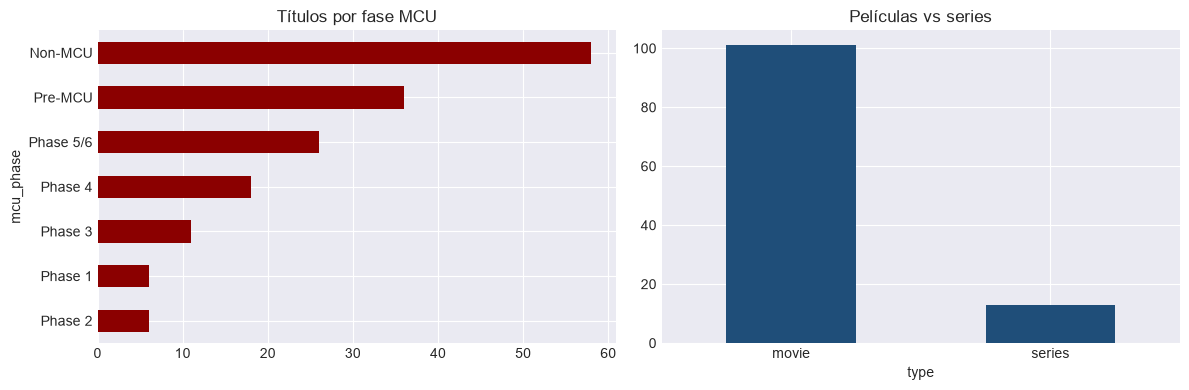

In [6]:
# Configuración del gráfico.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_master['mcu_phase'].value_counts().plot(kind='barh', ax=axes[0], color='#8B0000')
axes[0].set_title('Títulos por fase MCU')
axes[0].invert_yaxis()

df_master['type'].value_counts().plot(kind='bar', ax=axes[1], color='#1f4e79')
axes[1].set_title('Películas vs series')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Distribución de contenido del MCU y no-MCU.
df_master['is_mcu_canon'].value_counts(normalize=True)

is_mcu_canon
1    0.546584
0    0.453416
Name: proportion, dtype: float64

**Observaciones:** El dataset mezcla contenido previo a la creación del MCU por parte de Disney (producciones de Sony, Fox, TV clásica). Esto es importante para el diseño del retriever: hay que decidir si el asistente debe distinguir entre contenido MCU y no-MCU.

## Presupuesto, recaudación y ROI

In [10]:
# Filtramos por budget y revenue positivos.
fin = df_master[['title','year','budget_usd','revenue_usd']].dropna()
fin = fin[fin['budget_usd'] > 0]
fin['roi'] = fin['revenue_usd'] / fin['budget_usd']

print(f'Títulos con budget/revenue utilizables: {len(fin)} de {len(df_master)}')
fin.sort_values('roi', ascending=False).head(10)

Títulos con budget/revenue utilizables: 79 de 161


,title,year,budget_usd,revenue_usd,roi
71,Deadpool,2016,58000000.0,7.828373e+08,13.497196
124,Spider-Man: No Way Home,2021,200000000.0,2.019207e+09,10.096033
106,Avengers: Endgame,2019,356000000.0,2.799439e+09,7.863593
104,Captain Marvel,2019,152000000.0,1.131416e+09,7.443529
99,Venom,2018,116000000.0,8.560852e+08,7.380044
94,Deadpool 2,2018,110000000.0,7.858966e+08,7.144515
110,Spider-Man: Far From Home,2019,160000000.0,1.132723e+09,7.079520
139,Spider-Man: Across the Spider-Verse,2023,100000000.0,6.908979e+08,6.908979
50,The Avengers,2012,220000000.0,1.518816e+09,6.903707
93,Avengers: Infinity War,2018,300000000.0,2.052415e+09,6.841383


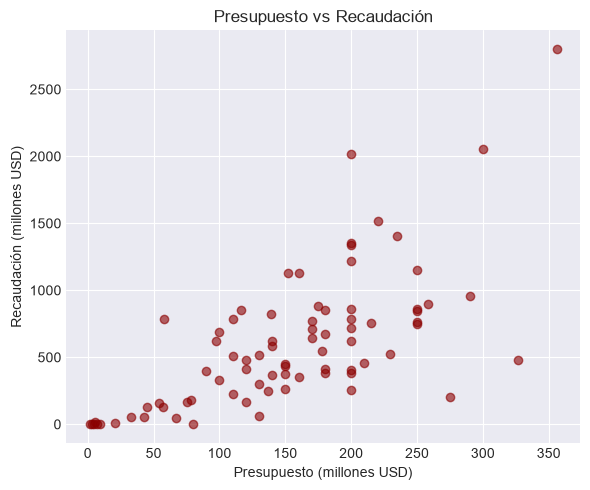

In [12]:
# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(fin['budget_usd']/1e6, fin['revenue_usd']/1e6, alpha=0.6, color='#8B0000')
ax.set_xlabel('Presupuesto (millones USD)')
ax.set_ylabel('Recaudación (millones USD)')
ax.set_title('Presupuesto vs Recaudación')
plt.tight_layout()
plt.show()

**Observaciones:** Hay una pequeña relación entre presupuesto y recaudación, de manera que generalmente (hay caso que no) cuanto mayor es el presupuesto, mayor es la recaudación.

## Ratings

In [ ]:
# Ratings de distintas fuentes.
df_ratings['source'].value_counts()

source
TMDB               161
IMDb               149
Rotten Tomatoes    125
Metacritic         119
Name: count, dtype: int64

In [20]:
# Cobertura.
cobertura = df_ratings.groupby(['title','year']).size().value_counts().sort_index()
cobertura.rename('n_titulos').rename_axis('n_fuentes_disponibles')

n_fuentes_disponibles
1     12
2     23
3      8
4    118
Name: n_titulos, dtype: int64

**Observaciones:** No todos los títulos tienen valoración por parte de las 4 fuentes de ratings. Hay que tenerlo en cuenta al construir preguntas de evaluación. Conviene fijar que fuente se usa por defecto o promediar solo las fuentes disponibles.

## Cast

In [21]:
cast_per_tile = df_cast.groupby(['title','year']).size()
print(cast_per_tile.describe())
cast_per_tile.value_counts().sort_index()

count    115.000000
mean      14.156522
std        2.607652
min        1.000000
25%       15.000000
50%       15.000000
75%       15.000000
max       15.000000
dtype: float64


1       1
3       1
4       1
6       2
7       1
8       2
10      2
12      1
13      3
14      1
15    100
Name: count, dtype: int64

**Observaciones:** el cast está capado a 15 actores por título (probablemente `top5_cast`
ampliado desde TMDB). 46 títulos de los 161 no tienen cast registrado;normal en
producciones de TV antiguas peor documentadas.

## Validación de clave de unión

`(title, year)`

In [24]:
# Unicidad en máster.
dup_master = df_master.duplicated(subset=['title','year']).sum()
print(f'Duplicados (title,year) en máster: {dup_master}')

# Cobertura: todas las claves de las tablas hijas existen en máster.
master_keys = set(zip(df_master['title'], df_master['year']))
for name, df in [('rag', df_rag), ('ratings', df_ratings), ('cast', df_cast)]:
    keys = set(zip(df['title'], df['year']))
    missing = keys - master_keys
    print(f'{name:10s} -> {len(keys)} claves, huérfanas: {len(missing)}')

Duplicados (title,year) en máster: 0
rag        -> 161 claves, huérfanas: 0
ratings    -> 161 claves, huérfanas: 0
cast       -> 115 claves, huérfanas: 0


**Conclusión:** `(title,year)` es una clave de unión válida y completa. Esta es la base que propaga `master.id` como
`media_id` (surrogate key) a las tablas hijas para simplificar los JOINs del futuro
SQL agent.

## Estructura de marvel_rag.csv (fuente para el índice vectorial)

In [26]:
print(df_rag.iloc[0]['document'])

Title: Captain America
Year: 1944
Universe: Pre-MCU
MCU Phase: Pre-MCU
Type: movie
Rated: Approved
Runtime: 244 minutes
Genre: Action, Adventure, Sci-Fi
Director: Elmer Clifton, John English
Writer: Royal K. Cole, Ronald Davidson, Basil Dickey
Cast: Dick Purcell, Lorna Gray, Lionel Atwill
Top 5 Cast: Dick Purcell, Lorna Gray, Lionel Atwill, Charles Trowbridge, Russell Hicks
Plot: Superhero Captain America battles the evil forces of the archvillain called The Scarab, who poisons his enemies and steals a secret device capable of destroying buildings by sound vibrations.
Tagline: 
Keywords: superhero, based on comic, masked vigilante, movie serial
IMDb Rating: 5.3
Rotten Tomatoes: None
Metacritic: None
TMDB Rating: 5.4
Box Office: N/A
Budget: 0
Revenue: 0
Awards: N/A
Collection: N/A
Country: United States
Language: English


In [27]:
# Número de chunks por título
df_rag.groupby('title').size().sort_values(ascending=False).head(10)

title
Captain America                      3
Spider-Man                           3
Fantastic Four                       3
Daredevil: Born Again                2
The Amazing Spider-Man               2
The Punisher                         2
The Incredible Hulk                  2
Agents of S.H.I.E.L.D. (Season 3)    1
Agents of S.H.I.E.L.D. (Season 4)    1
Ant-Man                              1
dtype: int64

**Observaciones:** Los títulos duplicados en título no son chunks del mismo documento, sino títulos homónimos de distinto año. Cada fila de marvel_rag.csv es un documento completo y autocontenido por (title, year), ya formateado en secciones, listo para chunking por entidad en la ingestión. 